# Quantum 0L State Encoding with a Color Code

In [34]:
%load_ext autoreload
%autoreload 2
    
from tsim import Circuit
import sinter
import numpy as np
import matplotlib.pyplot as plt
from tesseract_decoder import tesseract, TesseractSinterDecoder
from utils.no_decoder import NoDecoder
from utils.binomial_standard_error import binomial_standard_error as stat_err

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Code below  prepares the exact 0L  logical magic state
If the observable  evaluates to False (or 0= even parity), you have measured the logical $|\bar{0}\rangle$ state.
If it evaluates to True (or 1=odd parity), you have measured the logical $|\bar{1}\rangle$ state.

In [35]:
c = Circuit("""
    R 0 1 2 3 4 5 6
    SQRT_Y_DAG 0 1 2 3 4 5   
    CZ 1 2 3 4 5 6
    SQRT_Y 6
    CZ 0 3 2 5 4 6
    SQRT_Y 2 3 4 5 6
    CZ 0 1 2 3 4 5
    SQRT_Y 1 2 4
    X 3
    TICK
    #X 0 1 2 3 4 5 6  # change 0L --> 1L
    #X 0  # inject 1 error
    #X 0 2 # inject 2 errors
    M 0 1 2 3 4 5 6
    DETECTOR rec[-7] rec[-6] rec[-5] rec[-4]
    DETECTOR rec[-6] rec[-5] rec[-3] rec[-2]
    DETECTOR rec[-5] rec[-4] rec[-3] rec[-1]
    OBSERVABLE_INCLUDE(0) rec[-7] rec[-6] rec[-2]
    """)

tsim supports multiple visualization methods. The default makes use of `stim`'s "timeline-svg" visualization function:

In [36]:
c.diagram(height=350)

Tsim also supports visualization as a ZX diagram, where measurement vertices are annotated with `rec[i]`, and detector and observable vertices are annotated with `det[i]` and `obs[i]`, respectively.

In [37]:
c.diagram("pyzx");

To sample detection events and logical observables, we can compile a detector sampler, similar to `stim`.

In [38]:
det_sampler = c.compile_detector_sampler(seed=1)

In [39]:
det_samples, obs_samples = det_sampler.sample(shots=100_000, separate_observables=True)
print(det_samples[:5])
print(obs_samples[:5])

[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]]
[[False]
 [False]
 [False]
 [False]
 [False]]


In [40]:
print(f" prob(1L)= {int(np.count_nonzero(obs_samples)) / len(obs_samples)}")

 prob(1L)= 0.0


## Adding Noise

A core capability of tsim is its support for Pauli noise channels.

Let's look at a simple example. We'll insert a depolarizing channel `DEPOLARIZE1(0.01)` before the final stabilizer measurements.

In [41]:
def make_circuit(p):
    return Circuit(f"""
        R 0 1 2 3 4 5 6
        TICK
        SQRT_Y_DAG 0 1 2 3 4 5
        DEPOLARIZE1({p}) 0 1
        TICK
        CZ 1 2 3 4 5 6
        DEPOLARIZE2({p}) 1 2
        TICK
        SQRT_Y 6
        DEPOLARIZE1({p}) 6
        TICK
        CZ 0 3 2 5 4 6
        TICK
        SQRT_Y 2 3 4 5 6
        DEPOLARIZE1({p}) 2 4 6
        TICK
        CZ 0 1 2 3 4 5
        TICK
        DEPOLARIZE1({p}) 0 1 2 3 4 5 6
        SQRT_Y 1 2 4
        X 3
        TICK
        M 0 1 2 3 4 5 6
        DETECTOR rec[-7] rec[-6] rec[-5] rec[-4]
        DETECTOR rec[-6] rec[-5] rec[-3] rec[-2]
        DETECTOR rec[-5] rec[-4] rec[-3] rec[-1]
        OBSERVABLE_INCLUDE(0) rec[-7] rec[-6] rec[-2]
        """)


c = make_circuit(0.01)

In [42]:
c.diagram("timeline-svg", height=350)

In the ZX diagram, the noise is represented by parametrized vertices with binary parameters `e0`, `e1`, etc. Since a depolarizing channel either applies X, Y, Z gates, each channel requires two bits, i.e. an X and a Z vertex.

In [43]:
c.diagram("pyzx");

Now we compile the sampler for the noisy circuit.

In [44]:
det_sampler = c.compile_detector_sampler()

Sampling from the noisy circuit, we expect to see some non-zero detector events.

In [45]:
det_samples, obs_samples = det_sampler.sample(shots=10_000, separate_observables=True)
print(det_samples[:5], "\nTriggered detection events:", np.count_nonzero(det_samples))
print(obs_samples[:5])

[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]] 
Triggered detection events: 1437
[[False]
 [False]
 [False]
 [False]
 [False]]


We again calculate the probability of measuring a logical $|\bar{1}\rangle$. Due to the noise, it deviates from the ideal value of $\sin(\pi/8)^2 \approx 0.1464$.

In [46]:
int(np.count_nonzero(obs_samples)) / len(obs_samples)

0.031

## Error detection

One simple error correction strategy is **post-selection**: we discard any shots where a detector fired (indicating an error occurred). This effectively projects us back to the code space, but reduces the success rate (yield).

In [47]:
perfect_stabilizers = np.all(det_samples == 0, axis=1)
post_selected_obs = obs_samples[perfect_stabilizers]
int(np.count_nonzero(post_selected_obs)) / len(post_selected_obs)

0.0

## Error correction

To actively correct errors, we need a **decoder**. A decoder takes the detector syndrome and predicts whether the observable should be flipped.

In this example, we compare the [tesseract](https://github.com/quantumlib/tesseract-decoder) decoder to minimum-weight perfect matching (MWPM).

After correction, we see that both decoded probabilities are much closer to the ideal value.


In [48]:
c.detector_error_model()

stim.DetectorErrorModel('''
    error(0.0132444) D0 D1 D2
    error(0.0184365) D0 D1 L0
    error(0.00666667) D0 D2
    error(0.00666667) D0 L0
    error(0.0132444) D1 D2
    error(0.00666667) D1 L0
    error(0.0197345) D2
''')

In [49]:
dem = c.detector_error_model()

config = tesseract.TesseractConfig(dem=dem)
decoder = config.compile_decoder()

obs_tesseract = np.zeros_like(obs_samples)
for i, det_sample in enumerate(det_samples):
    flip_obs = decoder.decode(det_sample)
    obs_tesseract[i] = np.logical_xor(obs_samples[i], flip_obs[0])

# MWPM stands for Minimum Weight Perfect Matching
mwpm_predictions = sinter.predict_observables(
    dem=dem,
    dets=det_samples,
    decoder="pymatching",
    bit_pack_result=False,
)
obs_mwpm = np.logical_xor(obs_samples, mwpm_predictions)

N = len(obs_samples)
n_raw = int(np.count_nonzero(obs_samples))
n_mwpm = int(np.count_nonzero(obs_mwpm))
n_tess = int(np.count_nonzero(obs_tesseract))

print(f"Nshots: {N}")
print(f"Raw obs.:  {n_raw/N:.4f} +/- {stat_err(n_raw, N):.4f}")
print(f"MWPM:      {n_mwpm/N:.4f} +/- {stat_err(n_mwpm, N):.4f}")
print(f"Tesseract: {n_tess/N:.4f} +/- {stat_err(n_tess, N):.4f}")


Nshots: 10000
Raw obs.:  0.0310 +/- 0.0017
MWPM:      0.0151 +/- 0.0012
Tesseract: 0.0025 +/- 0.0005


## Monte Carlo Simulation with sinter

tsim is compatible with sinter, a tool for performing large Monte Carlo simulations. We can use sinter to sample and decode over a range of physical error rates.

In [52]:
tesseract_dec = TesseractSinterDecoder()
no_dec = NoDecoder()

shots_per_point = 1024 * 2

tasks = [
    sinter.Task(
        circuit=make_circuit(noise).cast_to_stim(),
        json_metadata={"p": noise},
    )
    for noise in np.logspace(-3.3, -0.2, 6)
]

collected_stats = sinter.collect(
    num_workers=1,
    tasks=tasks,
    decoders=["tesseract", "no decoding"],
    max_shots=shots_per_point,
    max_errors=shots_per_point,
    custom_decoders={"tesseract": tesseract_dec, "no decoding": NoDecoder()},
    start_batch_size=shots_per_point,
    max_batch_size=shots_per_point,
)

sinter provides a number of convenient plotting tools. Here, we compare no decoding, Tesseract, and MWPM by plotting the observable flip rate as a function of the physical error rate. The decoded probabilities approach the expected value of $\sin(\pi/8)^2$ much faster.

(1e-05, np.float64(1.0911470893139064))

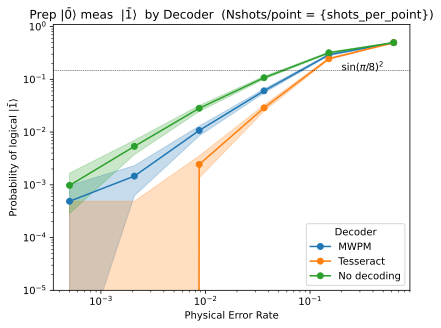

In [55]:
# Minimum-weight perfect matching (MWPM) via sinter's built-in pymatching decoder.
mwpm_stats = sinter.collect(
    num_workers=1,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=shots_per_point,
    max_errors=shots_per_point,
    start_batch_size=shots_per_point,
    max_batch_size=shots_per_point,
)

def curve(stats, decoder_name):
    pts = [(s.json_metadata["p"], s.errors, s.shots) for s in stats if s.decoder == decoder_name]
    pts.sort()
    x = np.array([p for p, _, _ in pts])
    y = np.array([n / N for _, n, N in pts])
    err = np.array([stat_err(n, N) for _, n, N in pts])
    return x, y, err

fig, ax = plt.subplots(1, 1)
all_stats = collected_stats + mwpm_stats
label_map = {"pymatching": "MWPM", "tesseract": "Tesseract", "no decoding": "No decoding"}
for decoder_name, label in label_map.items():
    x, y, err = curve(all_stats, decoder_name)
    if len(x) == 0:
        continue
    line, = ax.plot(x, y, marker="o", label=label)
    ax.fill_between(x, y - err, y + err, alpha=0.25, color=line.get_color())

ax.loglog()
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel(r"Probability of logical $|\bar{1}\rangle$")
ax.set_title(r"Prep $|\bar{0}\rangle$ meas  $|\bar{1}\rangle$  by Decoder  (Nshots/point = {shots_per_point})")
ax.axhline(np.sin(np.pi / 8) ** 2, color="k", linestyle="--", lw=0.4)
ax.text(0.2, np.sin(np.pi / 8) ** 2 * 1.01, r"$\sin(\pi/8)^2$", fontsize=10)
ax.legend(title="Decoder");

ax.set_ylim(bottom=1e-5)

Here is the matter-of-fact breakdown of exactly how the Tesseract decoder compares to the MWPM (Minimum Weight Perfect Matching) decoder, and what your code snippet is actually doing.

1. The Fundamental Difference
The easiest way to understand the difference is how they approach the problem of figuring out which errors occurred:

MWPM connects the dots. It looks at a 2D map of fired detectors and draws the shortest possible lines between them.

Tesseract explores the multiverse. It uses a search algorithm to test thousands of different hypothetical error scenarios, predicting how each scenario would play out until it finds the one that perfectly matches your data.

2. MWPM (The Traditional Standard)
As we discussed, MWPM creates a graph where fired detectors are nodes, and the most likely errors are the shortest edges connecting them.

The Math: It uses polynomial-time graph matching.

The Pros: It is incredibly fast. Software like PyMatching can decode massive surface codes in real-time.

The Cons: MWPM is strictly limited to codes where errors trigger exactly two detectors (like standard Surface Codes and some Color Codes). As the quantum industry moves toward more complex architectures like Low-Density Parity-Check (LDPC) and Bivariate-Bicycle codes (where a single error might trigger 3, 4, or 5 detectors), the standard MWPM graph breaks down and fails to map the logic correctly.

3. Tesseract (The Advanced Search Engine)
Tesseract is a completely different beast developed by Google Quantum AI. It is a Most-Likely Error (MLE) decoder.

Instead of just drawing lines, Tesseract formulates decoding as an exponentially large decision tree.

The Math: It uses the A (A-Star) search algorithm* mixed with a technique called Beam Search. It starts at the root (no errors) and branches out, adding possible errors one by one. To prevent your computer from crashing while searching an infinite tree, Tesseract aggressively "prunes" the bad branches (paths that are too improbable) and only climbs the branches that most closely match your measurement data.

The Pros: It is exceptionally accurate and extremely flexible. Because it relies on search rather than 2D geometry, it can decode highly complex LDPC codes, transversal logic gates, and weird hypergraphs that MWPM cannot comprehend.

The Cons: Because it is searching through an exponentially large mathematical space, it is fundamentally more computationally intensive than MWPM (though the C++ implementation is highly optimized to run as fast as possible).